### Постановка задачи
Целью обучения является прогнозирование будущих значений продаж на горизонте 16 дней. Для прогнозирования будут использоваться исторические признаки временных рядов, календартные признаки, а так же экзогенные. В ноутбуке будут рассмотрены простые baseline модели, модель машинного обучения и модель глубинного обучения.

### Протокол валидации
Так как в задачах прогнозирования временных рядов нельзя использовать случайное разбиение данных, для прогнозирования используется time-based валидация. Задача требует прогнозирование на горизонте 16 дней, поэтому в качестве валидационной выборки будут использоваться последние 16 дней.

### Метрика
Качество модели будет оцениваться с использованием метрики NWRMSLE (Normalized Weighted Root Mean Squared Logarithmic Error), которая используется в соревновании Kaggle. Она учитывает логарифм продаж и использует веса, заданные в таблице items под признаком perishable. Он показывает является ли товар скоропортящимся. Для скоропортящихся товаров определен вес 1.25, а для не скоропортящихся 1.0

### Импорт библиотек

In [ ]:
!pip install py7zr -q
!pip install statsforecast -q
!pip install pytorch_forecasting -q
!pip install lightning -q
!pip install --upgrade statsforecast -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.3/71.3 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 494.2/494.2 kB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.6/100.6 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.5/51.5 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.3/144.3 kB 8.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 354.6/354.6 kB 15.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 348.2/348.2 kB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 281.0/281.0 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 48.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.3/40.3 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.9/59.9 kB 3.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
!git clone https://github.com/llpscc/TimeSeries.git

Cloning into 'TimeSeries'...
remote: Enumerating objects: 95, done.
remote: Counting objects: 100% (95/95), done.
remote: Compressing objects: 100% (88/88), done.
remote: Total 95 (delta 38), reused 20 (delta 4), pack-reused 0 (from 0)
Receiving objects: 100% (95/95), 34.48 KiB | 1.44 MiB/s, done.
Resolving deltas: 100% (38/38), done.


In [ ]:
import sys
sys.path.append("/kaggle/working/TimeSeries")

In [ ]:
import os
import warnings
import logging
from pathlib import Path
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

warnings.filterwarnings("ignore")

logging.getLogger("lightning").setLevel(logging.ERROR)
logging.getLogger("pytorch_lightning").setLevel(logging.ERROR)
logging.getLogger("transformers").setLevel(logging.ERROR)

In [ ]:
import pandas as pd
import numpy as np
import random

from src.data import extract_data, load_data
from src.features import preprocess_train, select_top_items
from src.baseline import prepare_sf_data, run_baselines, train_val_split, merge_sf_forecast, compute_sf_metrics
from src.metrics import nwrmsle

from src.ml.dataset_ml import prepare_ml_data, prepare_test, test_categories, add_date_features, add_exogenous, add_lags
from src.ml.model_ml import prepare_data, set_categories, train_lgbm
from src.ml.inference_ml import recursive_forecast, build_history

from src.dl.dataset_dl import prepare_dl_dataset, build_tft_dataset
from src.dl.model_dl import build_tft, train_tft
from src.dl.inference_dl import predict_tft

from pipelines.predict import run_predict
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf
import lightgbm as lgb
import gc

### Загрузка данных

In [ ]:
import py7zr
from pathlib import Path

DATA_PATH = Path("/kaggle/input/competitions/favorita-grocery-sales-forecasting")
OUT_PATH = Path("/kaggle/working/favorita")

OUT_PATH.mkdir(exist_ok=True)

files = [
    "train.csv.7z",
    "test.csv.7z",
    "stores.csv.7z",
    "items.csv.7z",
    "oil.csv.7z",
    "holidays_events.csv.7z",
    "transactions.csv.7z",
    "sample_submission.csv.7z"
]

for file in files:
    with py7zr.SevenZipFile(DATA_PATH / file, mode="r") as z:
        z.extractall(path=OUT_PATH)

print("Done extracting!")

Done extracting!


In [ ]:
dtypes = {
    "store_nbr": "int8",
    "item_nbr": "int32",
    "unit_sales": "float32"
}

In [ ]:
DATA_PATH = Path("/kaggle/input/competitions/favorita-grocery-sales-forecasting")

train = pd.read_csv("/kaggle/working/favorita/train.csv", dtype=dtypes, parse_dates=["date"])
test = pd.read_csv("/kaggle/working/favorita/test.csv", dtype=dtypes,parse_dates=["date"])

stores = pd.read_csv("/kaggle/working/favorita/stores.csv", dtype=dtypes)
items = pd.read_csv("/kaggle/working/favorita/items.csv", dtype=dtypes)
oil = pd.read_csv("/kaggle/working/favorita/oil.csv", dtype=dtypes, parse_dates=["date"])
holidays = pd.read_csv("/kaggle/working/favorita/holidays_events.csv", dtype=dtypes, parse_dates=["date"])
transactions = pd.read_csv("/kaggle/working/favorita/transactions.csv", dtype=dtypes, parse_dates=["date"])

print(train.shape)

(125497040, 6)


### Семплирование, базовая предобработка и анализ рядов

Для экспериментов принято решение взять последний год данных, изначально были попытки обработать 2 года, но RAM Kaggle объемом 30gb не хватало для обучения финальной модели. Вероятно, это сильно повлияет на результат, но ресурсов для обучения на всем датасете нет :(

Обрезаем данные и приводим все колонки к нужному типу данных, используя функцию preprocess_train из модуля src.features

In [ ]:
train = preprocess_train(train)
print(train.shape)

(37358381, 6)


Посмотрим как выглядит датасет

In [ ]:
train.head()

,id,date,store_nbr,item_nbr,unit_sales,onpromotion
88138659,88138659,2016-08-16,1,105574,3.0,0
88138660,88138660,2016-08-16,1,105575,13.0,0
88138661,88138661,2016-08-16,1,105737,1.0,0
88138662,88138662,2016-08-16,1,105857,8.0,0
88138663,88138663,2016-08-16,1,106716,1.0,0


Типы данных

In [ ]:
train.dtypes

id                      int64
date           datetime64[ns]
store_nbr                int8
item_nbr                int32
unit_sales            float32
onpromotion             int64
dtype: object

Посмотрим, есть ли в данных пропуски

In [ ]:
print(f'В датасете {train.isna().sum().iloc[1]} пропусков')

В датасете 0 пропусков


Пропусков в используемом семпле не обнаружено. Посмотрим на графики 10 случайных рядов из датасета, чтобы оценить такие характеристики рядов, как частотность, выровненность, стационарность, а так же основные закономерности.

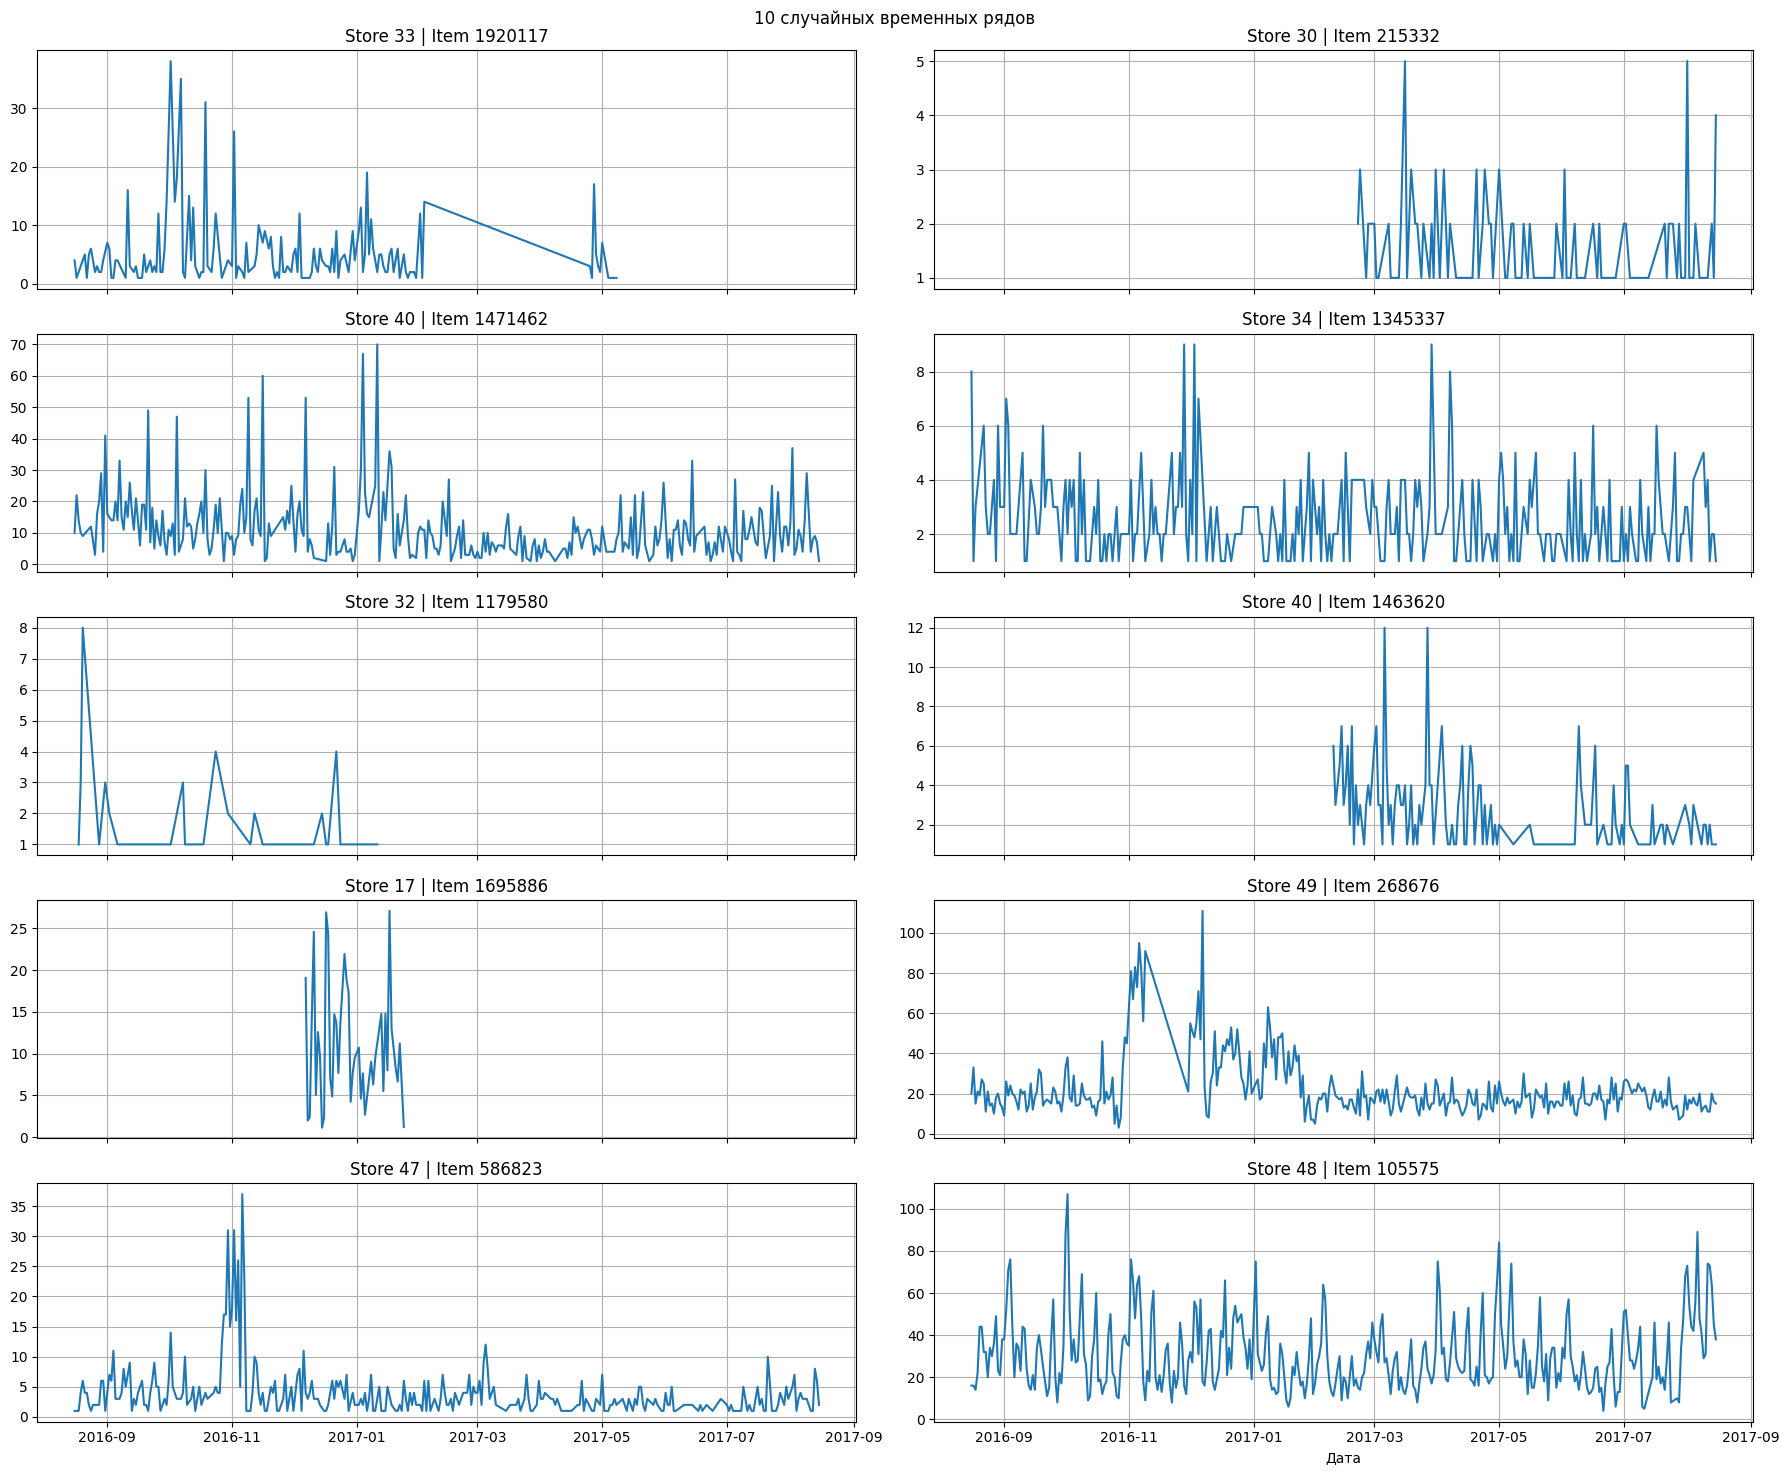

In [ ]:
# берем случайные ряды
random.seed(42)
series = (
    train[["store_nbr", "item_nbr"]]
    .drop_duplicates()
    .sample(10, random_state=42)
)

# строим графики
fig, axes = plt.subplots(5, 2, figsize=(18, 15), sharex=True)
axes = axes.flatten()

for i, (_, row) in enumerate(series.iterrows()):

    data = train[
        (train["store_nbr"] == row["store_nbr"]) &
        (train["item_nbr"] == row["item_nbr"])
    ]

    axes[i].plot(data["date"], data["unit_sales"])
    axes[i].set_title(f"Store {row['store_nbr']} | Item {row['item_nbr']}")
    axes[i].grid(True)

plt.xlabel("Дата")
plt.suptitle("10 случайных временных рядов")
plt.tight_layout()
plt.show()

Из данных таблицы, графиков и открытого описания данных, можно сделать следующие выводы:
1. Частосность наблюдений дневная. В таблице данные указаны по дням, а на графиках
2. Ряды не являются полностью выровненными. Некоторые ряды начинаются позже, другие имеют пустые участки. Часть товаров вообще появляется только в середине периода. Так как пропусков в данных не выявлено, можно предположить, что товары появляются в продаже в разные дни, некоторые товары могут временно отсутствовать или отсутствуют продажи.
3. Большинство рядов не стационарны. На некоторых можно выделить незначительный тренд среднего уровня продаж. В большинстве из примеров есть заметные изменения дисперсии, резкие скачки.
4. Ряды не похожи, но в целом имеют общую закономерность. Из похожих признаков у некоторых рядов можно выделить много нулевых или очень маленьких значений, у части рядов продажи относительно стабильные, а у других с резники пиками.

Так же можно заметить недельную сезонность, которую подтвердим графиком ниже

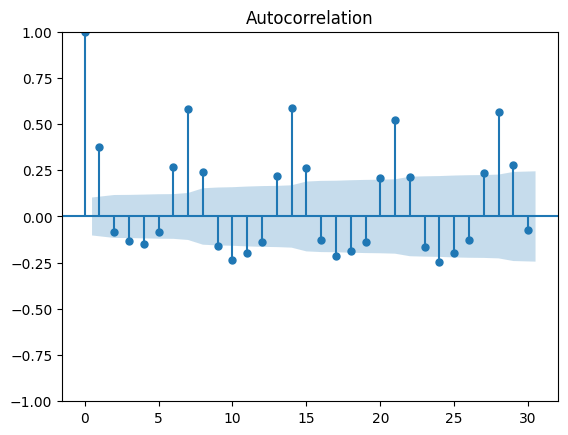

In [ ]:
series = train.groupby("date")["unit_sales"].sum()

plot_acf(series, lags=30)
plt.show()

Автокорреляция показывает выраженные пики на лагах 7, 14, 21 и 28, что окончательно подтверждает наличие недельной сезонности.

Посмотрим график суммарных продаж для каждой даты.

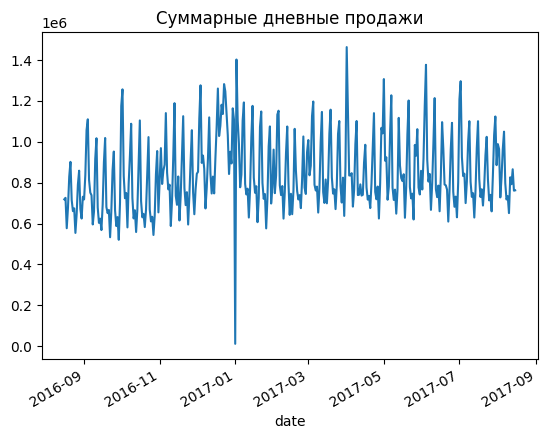

In [ ]:
train.groupby("date")["unit_sales"].sum().plot()
plt.title("Суммарные дневные продажи")
plt.show()

Тут так же видно выраженную сезонность и высокую вариативность продаж. Долгосрочный тренд отсутствует, однако присутствуют аномальные значения. Это делает задачу прогнозирования сложной и требует моделей, учитывающих временные зависимости.

Исходя из предварительного анализа и поставленной задачи, можно сразу зафиксировать следующие значения:

In [ ]:
HORIZON = 16 # горизонт прогнозирования, определенный соревнованием
START_TRAIN_SIZE = 180
STEP_SIZE = 7  # 1 неделя

SEASON_LENGTH = 7  # недельная сезонность
FREQ = "D"  # дневная частота


В соревновании используется метрика NWRMSLE. Она измеряет отклонение между истинными и предсказанными значениями продаж в логарифмическом масштабе.

#### Формула метрики
$$
NWRMSLE =
\sqrt{
\frac{\sum_{i=1}^{n} w_i \left(\log(1+\hat{y}_i) - \log(1+y_i)\right)^2}
{\sum_{i=1}^{n} w_i}
}
$$

где:

- $y_i$ — истинное значение продаж  
- $\hat{y}_i$ — предсказанное значение  
- $w_i$ — вес наблюдения  
- $n$ — количество наблюдений

### Бейзлайн

В качестве бейзлайна используются статистические модели Naive, SeasonalNaive, AutoETS и AutoTheta

Для сравнения моделей сначала я буду использовать сабсет из 5000 самых активных рядов. Это позволит оценить качество моделей и параметров быстро и без серьезных затрат ресурсов.
Для обучения бейзлайнов возьмем StatsForecast. Он оптимизированно и параллельно обучит все необходимые модели.

In [ ]:
train_5000 = select_top_items(train)
print(f'Первая дата в выборке: {train_5000['date'][0]}')

Первая дата в выборке: 2016-08-16 00:00:00


Для начала, приведем данные к необходимому виду. StatsForecast принимает данные в виде unique_id | ds | y

In [ ]:
sf_train = prepare_sf_data(train_5000)
print(sf_train.head())

        unique_id         ds     y
935    10_1052563 2016-08-16  34.0
5524   10_1052563 2016-08-17  36.0
10115  10_1052563 2016-08-18  18.0
14708  10_1052563 2016-08-19  21.0
19330  10_1052563 2016-08-20  35.0


На следующем этапе необходимо выделить валидационную выборку. В соревновании на Kaggle горизонт прогнозирования 16 дней, возьмем соответствующий период в качестве валидации.

In [ ]:
train_sf, val_sf = train_val_split(sf_train)
print(train_sf.shape, val_sf.shape)

(1629909, 3) (75146, 3)


Обучаем первые модели с использованием StatsForecast с использованием функции run_baselines из src.baseline.

In [ ]:
forecast = run_baselines(train_sf, val_sf, items)

Forecast:   0%|          | 0/400 [Elapsed: 00:00]

Добавляем прогнозы к реальным значениям и обрезаем возможные отрицательные предсказания

In [ ]:
eval_df = merge_sf_forecast(forecast, val_sf, items)

Оценим качество бейзлайнов для дальнейшего сравнения.

In [ ]:
metrics = compute_sf_metrics(eval_df)
print(metrics)

           Model   NWRMSLE
3      AutoTheta  1.094865
2        AutoETS  1.113895
0          Naive  1.119741
1  SeasonalNaive  1.136523


Полученные результаты показывают, что среди базовых моделей наилучшее качество демонстрирует AutoTheta, что связано с её способностью учитывать тренд и сезонные компоненты временного ряда. Модели AutoETS, Naive и SeasonalNaive показали более слабые результаты, так как они либо недостаточно гибко моделируют сезонность, либо опираются только на простые эвристики.

В целом, базовые модели служат хорошей отправной точкой для оценки сложности задачи, однако их точности недостаточно для практического применения. Это подтверждает необходимость использования более сложных моделей, способных учитывать дополнительные признаки и нелинейные зависимости в данных.

### Feature engeneering

Перед тем, как переходить к более сложным моделям, попробуем добавить несколько признаков для улучшения качества.

Следующая функция выполняет последовательно добавление экзогенных признаков, обработку столбца 'date', разделение на тренировочную и валидационную выборки и подсчет лагов и скользящих средних для тренировочной выборки.

Из столбца date извлекаются 4 новых признака: day_of_week, month, week_of_year и is_weekend.
Исходя из недельной сезонности данных, выбраны лаги 1, 7, 14 и 28. Скользящие средние - 7 и 14.

Этот этап позволит модели связать продажи и определенные дни между собой, а так же испротзовать поведение временного ряда за окно в прошлом.

In [ ]:
train_df_5000, val_df_5000 = prepare_ml_data(train_5000,items, stores, transactions, oil, HORIZON)

Посмотрим на тест

In [ ]:
train_df_5000.head()

,id,date,store_nbr,item_nbr,unit_sales,onpromotion,family,class,perishable,city,...,day_of_week,month,week_of_year,is_weekend,lag_1,lag_7,lag_14,lag_28,rolling_mean_7,rolling_mean_14
128503,90830706,2016-09-13,1,364606,69.0,0,GROCERY I,1014,0,Quito,...,1,9,37,0,35.0,47.0,26.0,31.0,29.857143,30.928571
133074,90922011,2016-09-14,1,364606,37.0,0,GROCERY I,1014,0,Quito,...,2,9,37,0,69.0,31.0,53.0,38.0,33.000000,34.000000
137633,91012242,2016-09-15,1,364606,45.0,0,GROCERY I,1014,0,Quito,...,3,9,37,0,37.0,32.0,44.0,37.0,33.857143,32.857143
142203,91103021,2016-09-16,1,364606,42.0,0,GROCERY I,1014,0,Quito,...,4,9,37,0,45.0,26.0,29.0,29.0,35.714286,32.928571
146832,91196998,2016-09-17,1,364606,34.0,0,GROCERY I,1014,0,Quito,...,5,9,37,1,42.0,24.0,32.0,25.0,38.000000,33.857143


И на валидацию

In [ ]:
val_df_5000.head()

,id,date,store_nbr,item_nbr,unit_sales,onpromotion,family,class,perishable,city,state,type,cluster,transactions,dcoilwtico,day_of_week,month,week_of_year,is_weekend
1629909,123819926,2017-07-31,1,364606,34.000,0,GROCERY I,1014,0,Quito,Pichincha,D,13,1872.0,50.21,0,7,31,0
1629910,123820021,2017-07-31,1,464374,62.000,1,BEVERAGES,1124,0,Quito,Pichincha,D,13,1872.0,50.21,0,7,31,0
1629911,123820061,2017-07-31,1,518091,16.000,0,BEVERAGES,1122,0,Quito,Pichincha,D,13,1872.0,50.21,0,7,31,0
1629912,123820115,2017-07-31,1,582864,34.598,0,MEATS,2302,1,Quito,Pichincha,D,13,1872.0,50.21,0,7,31,0
1629913,123820127,2017-07-31,1,584028,24.784,0,MEATS,2302,1,Quito,Pichincha,D,13,1872.0,50.21,0,7,31,0


### Модель машинного обучения
В качестве ML модели я выбираю LightGBM. Градиентный бустинг выбран, так как он устойчив к шуму, хорошо работает с нелинейными зависимостями и умеет выявлять сложные зависимости. LightGBM же выбран из-за скорости обучения. Датасет объемный и обучать CatBoost или XGBoost было бы значительно дольше.

Далее удалим колонки, которые не несут полезной информации, и выделим таргет. Функция prepare_data удалит из трейна колонки ["unit_sales", "date", "unique_id", 'id'], из теста будут удалены колонки ["unit_sales", "unique_id", 'id'], так как дата нам еще понадобится при построении рекурсивного прогноза. Дополнительно будет выделен таргет из обеих выборок.

In [ ]:
X_train, y_train, X_val, y_val = prepare_data(train_df_5000, val_df_5000)

Соберем категориальные признаки и выделим их в тип 'category' для LGBM.

In [ ]:
cat_cols = [
    "store_nbr",
    "item_nbr",
    "onpromotion",
    "family",
    "class",
    "perishable",
    "city",
    "state",
    "type",
    "cluster"
]
X_train, X_val = set_categories(X_train, X_val, cat_cols)

Обучаем LGBMRegressor c помощью функции train_lgbm из модуля src.ml.model_ml

In [ ]:
lgb_model = train_lgbm(X_train, y_train, cat_cols)

Для того, чтобы добавить лаги и скользящие средние, необходимо взять последние данные из трейна, чтобы сохранить хронологию рядов. Для этого воспользуемся функцией build_history из модуля src.ml.inference_ml

In [ ]:
history = build_history(train_df_5000)

Далее строим рекурсивный прогноз, чтобы оценить качество модели. Для рекурсивного прогноза используется функция recursive_forecast из модуля src.ml.inference_ml

In [ ]:
forecast_5000 = recursive_forecast(X_val, X_train, lgb_model, history, cat_cols)

Predicting: 100%|██████████| 16/16 [00:03<00:00,  4.54it/s]


Посмотрим качество модели и сравним с бейзлайном

In [ ]:
weights = np.where(forecast_5000["perishable"] == 1, 1.25, 1.0)

y_true = np.clip(y_val.values, 0, None)

lgbm_score = nwrmsle(
    y_true,
    forecast_5000["pred"].values,
    weights
)

metrics.loc[len(metrics)] = ["LightGBM", lgbm_score]
print("LightGBM NWRMSLE:", lgbm_score)

LightGBM NWRMSLE: 0.6034399848557029


In [ ]:
metrics = metrics.sort_values("NWRMSLE")
metrics

,Model,NWRMSLE
4,LightGBM,0.603440
3,AutoTheta,1.094865
2,AutoETS,1.113895
0,Naive,1.119741
1,SeasonalNaive,1.136523


Результат получился значительно лучше бейзлайна. LightGBM значительно превосходит базовые модели, значение метрики в два раза ниже. Это связано с тем, что бустинг отлично улавливает нелинейные зависимости между признаками, добавление дополнительных признаков так же играет не последнюю роль. Большим плюсом тут является скорость обучения.

Посмотрим на наиболее важные признаки

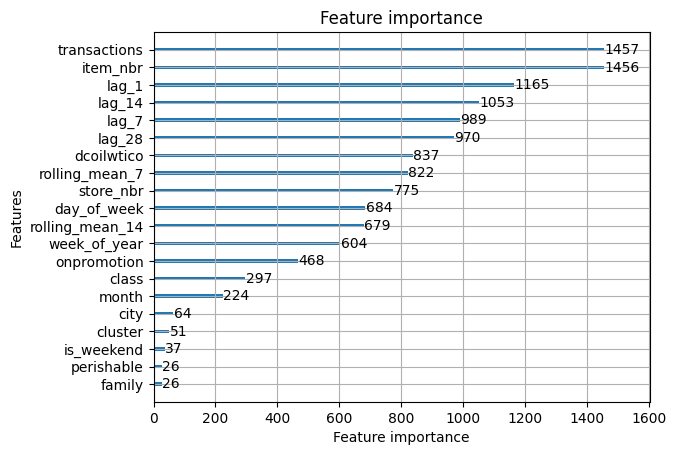

In [ ]:
lgb.plot_importance(lgb_model, max_num_features=20)
plt.show()

Наиболее важными признаками для LightGBM оказались item_bmr, transactions, а так же лаги, выделенные в процессе feature engineering. Значимость выделенных признаков day_of_week и week_of_yesr тоже весомая. Значения важности item_bmr и store_nbr указывают на то, что модель выделяет популярность конкретных магазиров.

### Глубинное обучение

Из DL моделей я возьму TFT. Она была разработана как раз под такие задачи, хорошо работает с табличными данными, экзогенными признаками и большим количеством рядов. Он способен предсказывать весь горизонт сразу и успешно работает с разными типами признаков.

Для начала создадим новые датафреймы, в которые добавим только экзогенные признаки и признаки, построенные на дате, так как лаги и скользящие статистики TFT учтет сама.



In [ ]:
train_5000 = add_date_features(train_5000)
train_5000 = add_exogenous(train_5000, items, stores, transactions, oil)

Следующая функция создает признак id ряда, сотрирует данные по хронологии и присваивает датам индексы. Далее происходит обрезание отрицательных таргетов и выделение границы трейна и валидации. Так же функция меняет тип данных в категориальных колонках на str и заполняет пропуски.

Среди признаков есть признак type, функция переименовывает его, чтобы у TFT не было с ним конфликта, так как внутри модели создается модуль self.type.

В процессе выполнения задания пропуски были обнаружены в столбцах transactions и dcoilwtico.Пропуски в transactions заполняются нулями, так как вероятно в эти периоды не было продаж.

dcoilwtico более сложный признак, он заполняется с помощью ffill, это заполнит ближайшим значением из прошлого, так как цена нефти обычно изменяется логично относительно соседних значений. Значения в начале ряда заполняем bfill, так они заполнятся ближайшим значением из будущего, так как ffill не заполнит их.


In [ ]:
categorical_cols = [
    "store_nbr",
    "item_nbr",
    "family",
    "class",
    "city",
    "cluster",
    "day_of_week",
    "week_of_year",
    "month",
    "onpromotion",
    'perishable'
]
dl_df, training_cutoff = prepare_dl_dataset(train_5000, HORIZON, categorical_cols)

Убедимся, что все пропуски заполнены

In [ ]:
dl_df.isna().sum()

id              0
date            0
store_nbr       0
item_nbr        0
unit_sales      0
onpromotion     0
day_of_week     0
month           0
week_of_year    0
is_weekend      0
family          0
class           0
perishable      0
city            0
state           0
store_type      0
cluster         0
transactions    0
dcoilwtico      0
series_id       0
time_idx        0
dtype: int64

Делим признаки на три группы для передачи в модель

In [ ]:
# статичные признаки
static_categoricals = [
    "store_nbr",
    "item_nbr",
    "family",
    "class",
    "perishable",
    "city",
    "state",
    "store_type",
    "cluster"
]

# признаки, которые известны в будущем
time_varying_known_reals = [
    "time_idx",
    "day_of_week",
    "month",
    "week_of_year",
    "is_weekend",
    "onpromotion"
]

# признаки, которые известны только в прошлом
time_varying_unknown_reals = [
    "unit_sales",
    "transactions",
    "dcoilwtico"
]

Теперь можно перейти к сборке датасета.

Следующая функция определяет training датасет. Она обрезает тренировочные данные по training_cutoff, берет группы признаков, нормализует таргет и создает дополнительные переменные индекс, масштаб ряда и длина истории для передачи в DataLoader. Далее с теми же парметрами создает val датасет.

In [ ]:
# encoder window
max_encoder_length = 60

In [ ]:
training, validation = build_tft_dataset(
    dl_df,
    training_cutoff,
    HORIZON,
    max_encoder_length,
    static_categoricals,
    time_varying_known_reals,
    time_varying_unknown_reals
)

Создаем train_loader и val_loader

In [ ]:
batch_size = 512

train_loader = training.to_dataloader(
    train=True,
    batch_size=batch_size,
    num_workers=0,
    pin_memory=True
)

val_loader = validation.to_dataloader(
    train=False,
    batch_size=batch_size,
    num_workers=0,
    pin_memory=True
)

Теперь приступим к обучению.

Параметры модели:

        learning_rate=1e-3,
        hidden_size=16,
        attention_head_size=4,
        dropout=0.1,
        hidden_continuous_size=16,
        loss=QuantileLoss(),
        output_size=7,
        max_epochs = 3

  

In [ ]:
# модель
build_model = build_tft(training)

model = train_tft(build_model, train_loader, val_loader)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


┏━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name                               ┃ Type                            ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ loss                               │ QuantileLoss                    │      0 │ train │     0 │
│ 1  │ logging_metrics                    │ ModuleList                      │      0 │ train │     0 │
│ 2  │ input_embeddings                   │ MultiEmbedding                  │ 17.0 K │ train │     0 │
│ 3  │ prescalers                         │ ModuleDict                      │    416 │ train │     0 │
│ 4  │ static_variable_selection          │ VariableSelectionNetwork        │  6.0 K │ train │     0 │
│ 5  │ encoder_variable_selection         │ VariableSelectionNetwork        │ 13.7 K │ train │     0 │
│ 6  │ decoder_variable_selection         │ VariableSelectionNetwork        │  9.2 K │ train │     0 │
│ 7  │ static_context_variable_selection  │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 8  │ static_context_initial_hidden_lstm │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 9  │ static_context_initial_cell_lstm   │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 10 │ static_context_enrichment          │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 11 │ lstm_encoder                       │ LSTM                            │  2.2 K │ train │     0 │
│ 12 │ lstm_decoder                       │ LSTM                            │  2.2 K │ train │     0 │
│ 13 │ post_lstm_gate_encoder             │ GatedLinearUnit                 │    544 │ train │     0 │
│ 14 │ post_lstm_add_norm_encoder         │ AddNorm                         │     32 │ train │     0 │
│ 15 │ static_enrichment                  │ GatedResidualNetwork            │  1.4 K │ train │     0 │
│ 16 │ multihead_attn                     │ InterpretableMultiHeadAttention │    676 │ train │     0 │
│ 17 │ post_attn_gate_norm                │ GateAddNorm                     │    576 │ train │     0 │
│ 18 │ pos_wise_ff                        │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 19 │ pre_output_gate_norm               │ GateAddNorm                     │    576 │ train │     0 │
│ 20 │ output_layer                       │ Linear                          │    119 │ train │     0 │
└────┴────────────────────────────────────┴─────────────────────────────────┴────────┴───────┴───────┘

Trainable params: 59.5 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 59.5 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 417                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

`Trainer.fit` stopped: `max_epochs=3` reached.


Следующая функция выводит предсказания модели и веса. Она последовательно получает предсказания, выравнивает массивы, обрезает отрицательные значения

In [ ]:
# предсказания
y_true, y_pred, weights = predict_tft(model, val_loader, items, HORIZON)

Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


Считаем метрику

In [ ]:
# метрика
tft_score = nwrmsle(
    y_true,
    y_pred,
    weights
)

print("TFT NWRMSLE:", tft_score)

TFT NWRMSLE: 0.6018561548001745


Сравним все полученные результаты

In [ ]:
metrics = metrics.sort_values("NWRMSLE")
metrics

,Model,NWRMSLE
5,TFT,0.601856
4,LightGBM,0.603440
3,AutoTheta,1.094865
2,AutoETS,1.113895
0,Naive,1.119741
1,SeasonalNaive,1.136523


### Заключительный этап

По таблице видно, что LightGBM и TFT дали сопоставимый результат, так как оба улавливают сложные зависимости, сезонность и незначительные тренды. Для финального предсказания был выбран LightGBM, так как его обучение занимает гораздо меньше времени при сопоставимых результатах. Возможно, будь у TFT больше эпох, меньше батчи или больше данных, он показал бы лучший результат, но в данный момент ресурсы ограничены и выбор был сделан в пользу более легкой модели, которая показала лучший результат в имеющихся условиях.

Далее будем обучать на нем весь sample данных за год, чтобы получить финальный результат. Для начала повторим на данных все этапы feature engeneering.

In [ ]:
# добавляем признаки даты и экзогенные, делим семпл на тренировочную и валидационную
full_train_df, full_val_df = prepare_ml_data(train, items, stores, transactions, oil, HORIZON)

In [ ]:
# удаление лишних столбцов и выделение таргета и валидации
X_train, y_train, X_val, y_val = prepare_data(full_train_df, full_val_df)

# очистка RAM
gc.collect()

7342

In [ ]:
# категориальные колонки
cat_cols = [
    "store_nbr",
    "item_nbr",
    "onpromotion",
    "family",
    "class",
    "perishable",
    "city",
    "state",
    "type",
    "cluster"
]
X_train, X_val = set_categories(X_train, X_val, cat_cols)

In [ ]:
X_val.head()

,date,store_nbr,item_nbr,onpromotion,family,class,perishable,city,state,type,cluster,transactions,dcoilwtico,day_of_week,month,week_of_year,is_weekend
35681037,2017-07-31,1,96995,0,GROCERY I,1093,0,Quito,Pichincha,D,13,1872.0,50.21,0,7,31,0
35681038,2017-07-31,1,103520,0,GROCERY I,1028,0,Quito,Pichincha,D,13,1872.0,50.21,0,7,31,0
35681039,2017-07-31,1,103665,0,BREAD/BAKERY,2712,1,Quito,Pichincha,D,13,1872.0,50.21,0,7,31,0
35681040,2017-07-31,1,105574,0,GROCERY I,1045,0,Quito,Pichincha,D,13,1872.0,50.21,0,7,31,0
35681041,2017-07-31,1,105575,0,GROCERY I,1045,0,Quito,Pichincha,D,13,1872.0,50.21,0,7,31,0


Запускаем обучение, получаем историю, запускаем рекурсивное предсказание и считаем метрику на валидации.

In [ ]:
# обучение
lgb_model = train_lgbm(X_train, y_train, cat_cols)

In [ ]:
# история и предсказание
history = build_history(full_train_df)
full_forecast = recursive_forecast(X_val, X_train, lgb_model, history, cat_cols)

Predicting: 100%|██████████| 16/16 [00:56<00:00,  3.50s/it]


Посмотрим качество модели и сравним с бейзлайном

In [ ]:
weights = np.where(full_forecast["perishable"] == 1, 1.25, 1.0)

y_true = np.clip(y_val.values, 0, None)

lgbm_score = nwrmsle(
    y_true,
    full_forecast["pred"].values,
    weights
)

print("LightGBM Full NWRMSLE:", lgbm_score)

LightGBM Full NWRMSLE: 0.5567039429383618


Посмотрим на визуализацию реальзых и предсказанных значений валидационной выборки.

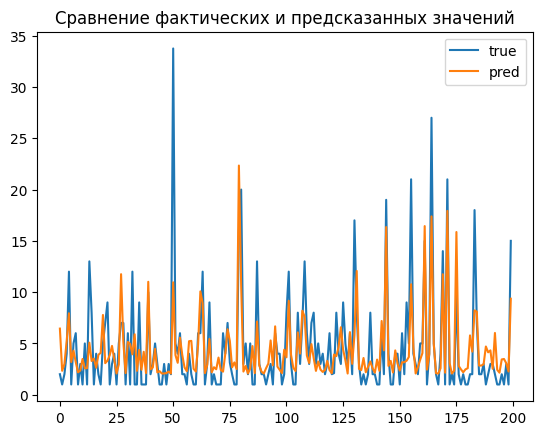

In [ ]:
y_pred = full_forecast['pred']
plt.plot(y_true[:200], label="true")
plt.plot(y_pred[:200], label="pred")
plt.title("Сравнение фактических и предсказанных значений")
plt.legend()
plt.show()

Результат с данными за год получился, ожидаемо, лучше. С бОльшим количеством данных, модель хорошо воспроизводит общий уровень и динамику продаж, но видно что она сглаживает пики и хуже предсказывает резкие всплески.

Теперь нужно сделать предсказание на тестовых данных, чтобы проверить обобщающую способность модели.
Сначала подготовим тестовую выборку, пропустим ее через все этапы обработки и feature engeneering.

In [ ]:
test = prepare_test(test, items, stores, transactions, oil)

# проверим пропуски
print(f'В датасете {test.isna().sum().iloc[1]} пропусков')

В датасете 0 пропусков


In [ ]:
# категориальные колонки
cat_cols = [
    "store_nbr",
    "item_nbr",
    "onpromotion",
    "family",
    "class",
    "perishable",
    "city",
    "state",
    "type",
    "cluster"
]

test = test_categories(test, cat_cols)

Добавляем лаги и скользящие средние в train, чтобы получить корректную историю

In [ ]:
train = add_lags(train)

И делаем рекурсивный прогноз

In [ ]:
pred_test = recursive_forecast(test, X_train, lgb_model, history, cat_cols)

Predicting: 100%|██████████| 16/16 [01:54<00:00,  7.13s/it]


Подготовим файл для загрузки в соревнование

In [ ]:
sample = pd.read_csv("/kaggle/working/favorita/sample_submission.csv")

In [ ]:
submission = sample.drop(columns="unit_sales").merge(
    pred_test[["id", "pred"]],
    on="id",
    how="left"
)

submission = submission.rename(columns={"pred": "unit_sales"})
submission.to_csv("/kaggle/working/submission.csv", index=False)

На картинке ниже можно увидеть неболльшую часть из попыток исправить ошибки и улучшить результат :)
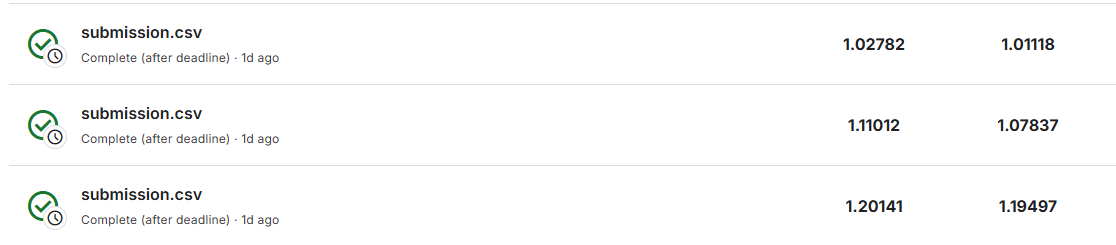

Как и предполагалось, результат не очень. Скорее всего, если обучить модель на всем датасете, результат был бы значительно лучше. Так же результат может улучшить более серьезный feature engeneering.